In [1]:
import warnings
warnings.filterwarnings("ignore")

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
logger = logging.getLogger("ames_notebook")
logger.setLevel(logging.INFO)

if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(levelname)s - %(message)s"))
    logger.addHandler(handler)

logger.propagate = False
logger.info("Logger is gestart")

INFO - Logger is gestart


In [3]:
bestand = "AmesHousing.xlsx"

df = pd.read_excel(bestand, sheet_name="AmesHousing")
data_dictionary = pd.read_excel(bestand, sheet_name="Data Dictionary")

logger.info(f"Dataset ingeladen met shape: {df.shape}")
df.head()

INFO - Dataset ingeladen met shape: (2930, 12)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [4]:
data_dictionary.head(20)

,Variabele,Betekenis
0,ID,"Uniek nummer per huis, te vergelijken met een ..."
1,SalePrice,Verkoopprijs van het huis (in dollars: USD)
2,Garage,Geeft weer of het huis wel/geen garage bevat
3,Overall Qual,Algemene kwaliteit van materialen en afwerking...
4,Gr Liv Area,Woonoppervlak boven de grond (square feet)
5,Total Bsmt SF,Totale oppervlakte van de kelder
6,Lot Area,Grootte van het perceel (square feet)
7,Year Built,Bouwjaar van het huis
8,Full Bath,Aantal volledige badkamers
9,Bedroom AbvGr,Aantal slaapkamers boven de grond


In [5]:
df.columns.tolist()

['ID',
 'SalePrice',
 'Garage',
 'Overall Qual',
 'Gr Liv Area',
 'Total Bsmt SF',
 'Lot Area',
 'Year Built',
 'Full Bath',
 'Bedroom AbvGr',
 'Neighborhood',
 'House Style']

In [6]:
target = "SalePrice"
features = ["Overall Qual", "Gr Liv Area", "Neighborhood"]

logger.info(f"Gekozen target: {target}")
logger.info(f"Gekozen features: {features}")

INFO - Gekozen target: SalePrice
INFO - Gekozen features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood']


In [7]:
data = df[features + [target]].copy()
data.head()

,Overall Qual,Gr Liv Area,Neighborhood,SalePrice
0,6,1656,NAmes,215000
1,5,896,NAmes,105000
2,6,1329,NAmes,172000
3,7,2110,NAmes,244000
4,5,1629,Gilbert,189900


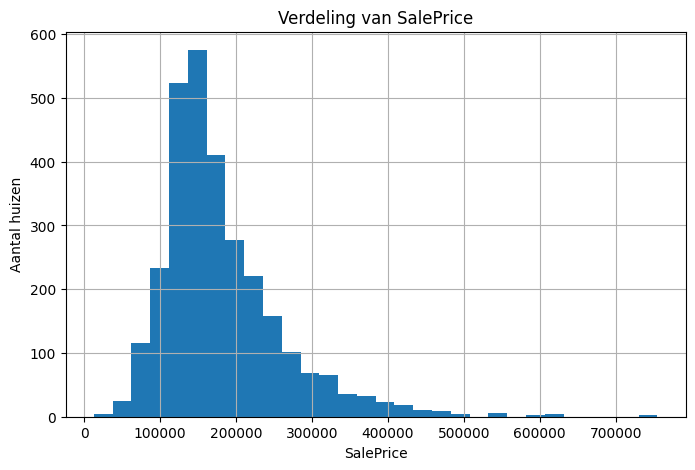

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(data[target].dropna(), bins=30)
plt.title("Verdeling van SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Aantal huizen")
plt.grid(True)
plt.show()

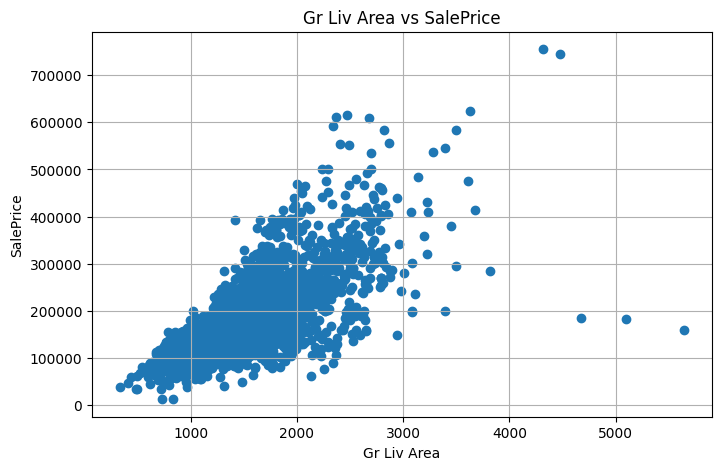

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(data["Gr Liv Area"], data[target])
plt.title("Gr Liv Area vs SalePrice")
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.grid(True)
plt.show()

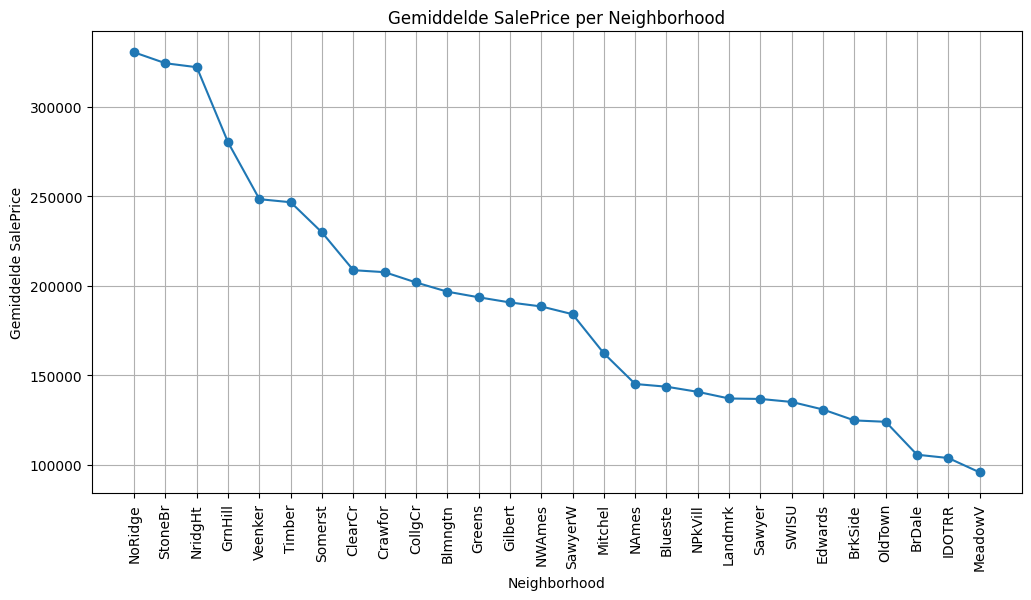

In [10]:
gemiddelde_prijs = data.groupby("Neighborhood")[target].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(gemiddelde_prijs.index, gemiddelde_prijs.values, marker="o")
plt.title("Gemiddelde SalePrice per Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Gemiddelde SalePrice")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [11]:
data = data.dropna(subset=[target])

X = data[features]
y = data[target]

logger.info(f"X shape: {X.shape}")
logger.info(f"y shape: {y.shape}")

INFO - X shape: (2930, 3)
INFO - y shape: (2930,)


In [12]:
help(SGDRegressor)

Help on class SGDRegressor in module sklearn.linear_model._stochastic_gradient:

class SGDRegressor(BaseSGDRegressor)
 |  SGDRegressor(
 |      loss='squared_error',
 |      *,
 |      penalty='l2',
 |      alpha=0.0001,
 |      l1_ratio=0.15,
 |      fit_intercept=True,
 |      max_iter=1000,
 |      tol=0.001,
 |      shuffle=True,
 |      verbose=0,
 |      epsilon=0.1,
 |      random_state=None,
 |      learning_rate='invscaling',
 |      eta0=0.01,
 |      power_t=0.25,
 |      early_stopping=False,
 |      validation_fraction=0.1,
 |      n_iter_no_change=5,
 |      warm_start=False,
 |      average=False
 |  )
 |
 |  Linear model fitted by minimizing a regularized empirical loss with SGD.
 |
 |  SGD stands for Stochastic Gradient Descent: the gradient of the loss is
 |  estimated each sample at a time and the model is updated along the way with
 |  a decreasing strength schedule (aka learning rate).
 |
 |  The regularizer is a penalty added to the loss function that shrinks mode

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

logger.info(f"X_train shape: {X_train.shape}")
logger.info(f"X_test shape: {X_test.shape}")
logger.info(f"y_train shape: {y_train.shape}")
logger.info(f"y_test shape: {y_test.shape}")

INFO - X_train shape: (2344, 3)
INFO - X_test shape: (586, 3)
INFO - y_train shape: (2344,)
INFO - y_test shape: (586,)


In [14]:
categorische_kolommen = X.select_dtypes(include=["object"]).columns.tolist()
numerieke_kolommen = [kolom for kolom in X.columns if kolom not in categorische_kolommen]

logger.info(f"Categorische kolommen: {categorische_kolommen}")
logger.info(f"Numerieke kolommen: {numerieke_kolommen}")

INFO - Categorische kolommen: ['Neighborhood']
INFO - Numerieke kolommen: ['Overall Qual', 'Gr Liv Area']


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerieke_kolommen
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorische_kolommen
        )
    ]
)

In [16]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", SGDRegressor(
        max_iter=1000,
        eta0=0.0001,
        learning_rate="constant",
        random_state=42
    ))
])

logger.info("Model aangemaakt")

INFO - Model aangemaakt


In [17]:
model.fit(X_train, y_train)
logger.info("Model is getraind")

INFO - Model is getraind


In [18]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Waarde": [mae, mse, rmse, r2]
})

,Metric,Waarde
0,MAE,2.553747e+04
1,MSE,1.573827e+09
2,RMSE,3.967148e+04
3,R2,8.037023e-01


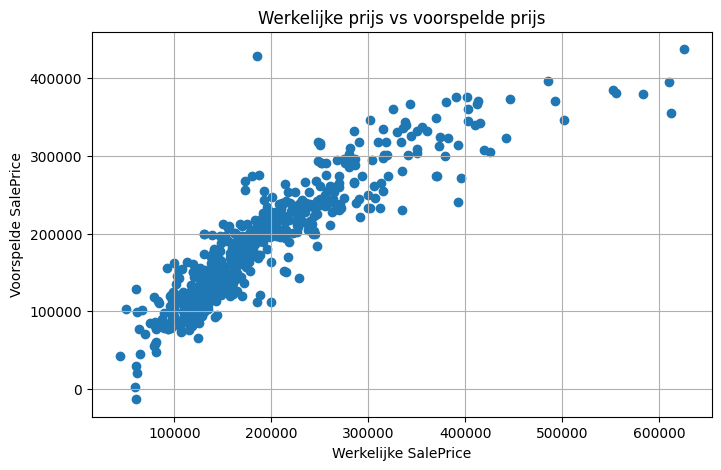

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.title("Werkelijke prijs vs voorspelde prijs")
plt.xlabel("Werkelijke SalePrice")
plt.ylabel("Voorspelde SalePrice")
plt.grid(True)
plt.show()

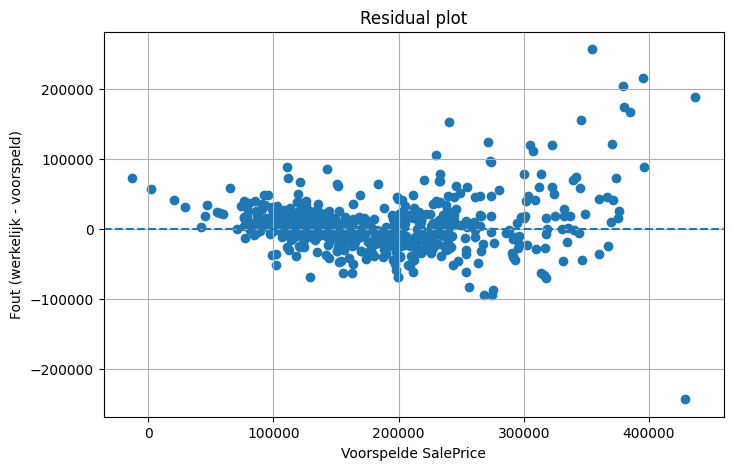

In [20]:
residuals = y_test.to_numpy() - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.title("Residual plot")
plt.xlabel("Voorspelde SalePrice")
plt.ylabel("Fout (werkelijk - voorspeld)")
plt.grid(True)
plt.show()

In [21]:
def voer_experiment_uit(df, features, target, max_iter, eta0, learning_rate="constant", run_naam="Run"):
    data = df[features + [target]].copy()
    data = data.dropna(subset=[target])

    X = data[features]
    y = data[target]

    categorische_kolommen = X.select_dtypes(include=["object"]).columns.tolist()
    numerieke_kolommen = [kolom for kolom in X.columns if kolom not in categorische_kolommen]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numerieke_kolommen
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorische_kolommen
            )
        ]
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", SGDRegressor(
            max_iter=max_iter,
            eta0=eta0,
            learning_rate=learning_rate,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        "Run": run_naam,
        "Features": ", ".join(features),
        "max_iter": max_iter,
        "eta0": eta0,
        "learning_rate": learning_rate,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "y_test": y_test.to_numpy(),
        "y_pred": y_pred
    }

In [22]:
experimenten = [
    {
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood"],
        "max_iter": 1000,
        "eta0": 0.0001,
        "learning_rate": "constant",
        "run_naam": "Initiële run"
    },
    {
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "Year Built"],
        "max_iter": 1500,
        "eta0": 0.0001,
        "learning_rate": "constant",
        "run_naam": "Experiment 1"
    },
    {
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Year Built"],
        "max_iter": 2000,
        "eta0": 0.0005,
        "learning_rate": "constant",
        "run_naam": "Experiment 2"
    },
    {
        "features": ["Overall Qual", "Gr Liv Area", "Neighborhood", "House Style", "Year Built", "Total Bsmt SF"],
        "max_iter": 3000,
        "eta0": 0.001,
        "learning_rate": "constant",
        "run_naam": "Experiment 3"
    }
]

In [23]:
alle_runs = []

for exp in experimenten:
    run_resultaat = voer_experiment_uit(
        df=df,
        features=exp["features"],
        target=target,
        max_iter=exp["max_iter"],
        eta0=exp["eta0"],
        learning_rate=exp["learning_rate"],
        run_naam=exp["run_naam"]
    )
    alle_runs.append(run_resultaat)

In [24]:
resultaten_df = pd.DataFrame([
    {
        "Run": run["Run"],
        "Features": run["Features"],
        "max_iter": run["max_iter"],
        "eta0": run["eta0"],
        "learning_rate": run["learning_rate"],
        "MAE": run["MAE"],
        "MSE": run["MSE"],
        "RMSE": run["RMSE"],
        "R2": run["R2"]
    }
    for run in alle_runs
])

resultaten_df

,Run,Features,max_iter,eta0,learning_rate,MAE,MSE,RMSE,R2
0,Initiële run,"Overall Qual, Gr Liv Area, Neighborhood",1000,0.0001,constant,25537.471931,1.573827e+09,39671.482872,0.803702
1,Experiment 1,"Overall Qual, Gr Liv Area, Neighborhood, Year ...",1500,0.0001,constant,24936.742940,1.536088e+09,39192.953487,0.808409
2,Experiment 2,"Overall Qual, Gr Liv Area, Neighborhood, House...",2000,0.0005,constant,23509.153173,1.396630e+09,37371.518426,0.825803
3,Experiment 3,"Overall Qual, Gr Liv Area, Neighborhood, House...",3000,0.0010,constant,23654.683272,1.379322e+09,37139.230862,0.827962


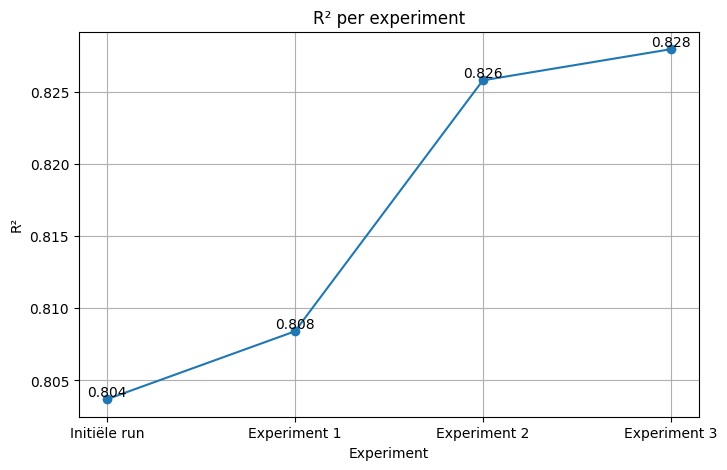

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(resultaten_df["Run"], resultaten_df["R2"], marker="o")

for x, y in zip(resultaten_df["Run"], resultaten_df["R2"]):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom")

plt.title("R² per experiment")
plt.xlabel("Experiment")
plt.ylabel("R²")
plt.grid(True)
plt.show()

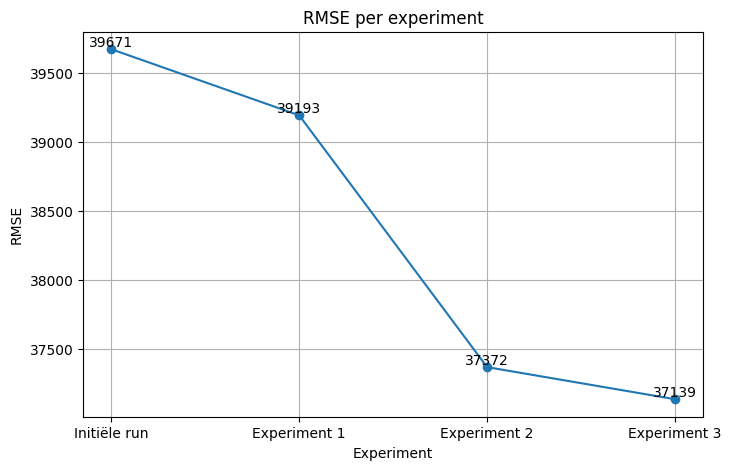

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(resultaten_df["Run"], resultaten_df["RMSE"], marker="o")

for x, y in zip(resultaten_df["Run"], resultaten_df["RMSE"]):
    plt.text(x, y, f"{y:.0f}", ha="center", va="bottom")

plt.title("RMSE per experiment")
plt.xlabel("Experiment")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

In [27]:
beste_run_naam = resultaten_df.sort_values(by="R2", ascending=False).iloc[0]["Run"]
beste_run_data = next(run for run in alle_runs if run["Run"] == beste_run_naam)

resultaten_df[resultaten_df["Run"] == beste_run_naam]

,Run,Features,max_iter,eta0,learning_rate,MAE,MSE,RMSE,R2
3,Experiment 3,"Overall Qual, Gr Liv Area, Neighborhood, House...",3000,0.001,constant,23654.683272,1.379322e+09,37139.230862,0.827962


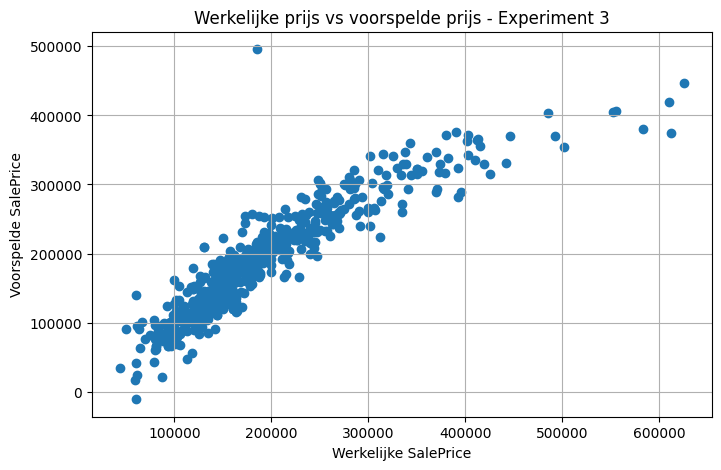

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(beste_run_data["y_test"], beste_run_data["y_pred"])
plt.title(f"Werkelijke prijs vs voorspelde prijs - {beste_run_naam}")
plt.xlabel("Werkelijke SalePrice")
plt.ylabel("Voorspelde SalePrice")
plt.grid(True)
plt.show()

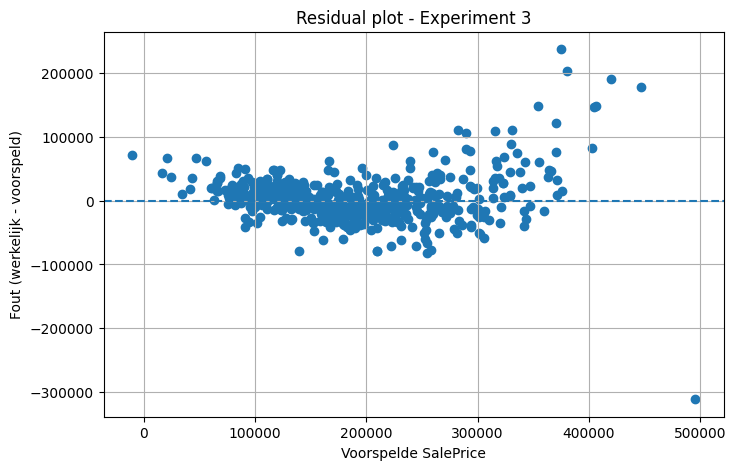

In [29]:
beste_residuals = beste_run_data["y_test"] - beste_run_data["y_pred"]

plt.figure(figsize=(8, 5))
plt.scatter(beste_run_data["y_pred"], beste_residuals)
plt.axhline(y=0, linestyle="--")
plt.title(f"Residual plot - {beste_run_naam}")
plt.xlabel("Voorspelde SalePrice")
plt.ylabel("Fout (werkelijk - voorspeld)")
plt.grid(True)
plt.show()